In [2]:

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import sys
import os

# Get the current working directory (where the notebook is located)
current_dir = os.getcwd()

# Get the parent directory
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))

# Add the parent directory to sys.path
sys.path.insert(0, parent_dir)

from data_creator import load_2D
df = load_2D().dropna() # load data from files


In [9]:



X = df[['Area', 'Circumference', 'CoA', 'MU', "Span", "MCS"]]

scale = StandardScaler()
scaled_X = scale.fit_transform(X)
y = (df["AD"] > df["ADPass"]).astype(int)  # Convert boolean to int (0 or 1)
X_train, X_test, y_train, y_test = train_test_split(scaled_X, y, test_size = 0.25, random_state = 42)


In [11]:

from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt





🔍 Kernel: linear
Accuracy: 0.9390
ROC AUC : 0.9209


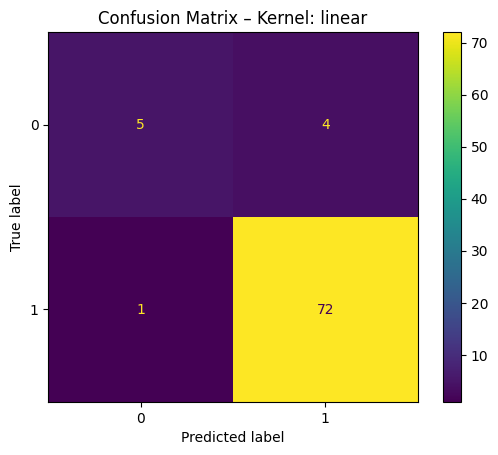


🔍 Kernel: poly
Accuracy: 0.9268
ROC AUC : 0.9513


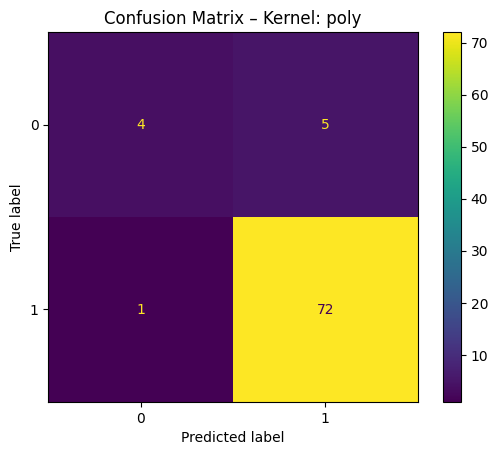


🔍 Kernel: rbf
Accuracy: 0.9268
ROC AUC : 0.8980


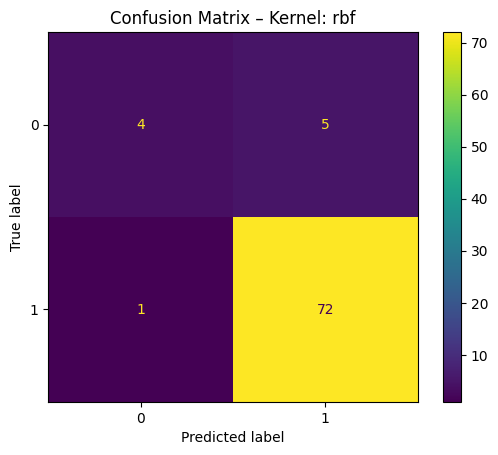


🔍 Kernel: sigmoid
Accuracy: 0.8780
ROC AUC : 0.5784


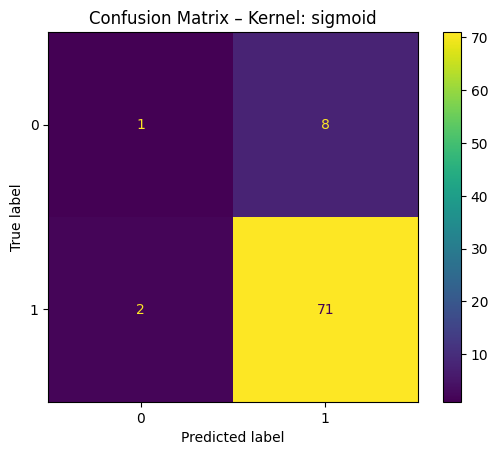

In [15]:
# Try different SVC kernels
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
svc_results=[]
for kernel in kernels:
    print(f"\n🔍 Kernel: {kernel}")

    svc_model = make_pipeline(
        StandardScaler(),
        SVC(kernel=kernel, C=10, gamma='auto', probability=True)  # probability=True if you want ROC AUC
    )

    svc_model.fit(X_train, y_train)
    y_pred = svc_model.predict(X_test)
    y_prob = svc_model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    svc_results.append({
        "Kernel": kernel,
        "Accuracy": accuracy,
        "ROC_AUC": roc_auc,
        "y_test": y_test.tolist(),
        "y_pred": y_pred.tolist(),
        "y_prob": y_prob.tolist()
    })

    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC AUC : {roc_auc:.4f}")

    cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    cm.ax_.set_title(f"Confusion Matrix – Kernel: {kernel}")
    plt.show()

[0.9347896829677363, 0.9844610031072301, 0.98177452856519, 0.9509379229243101, 0.9131405832045216, 0.9333038160298998, 0.9064639125057865, 0.7776656099221326, 0.9702818836638347, 0.8920469947409752, 0.9021643528503902, 0.9214896157977993, 0.8963791366779328, 0.9879921538306327, 0.9496703792830473, 0.9893177850044682, 0.9827077624390141, 0.9778865004083018, 0.9888862548919239, 0.9084052638879824, 0.9148067612644255, 0.9058316125900946, 0.8954675675749623, 0.933595006457235, 0.9180898270066867, 0.9848626317553227, 0.9112274810248359, 0.9725059952185512, 0.9626491861339099, 0.9441136474545242, 0.9382500822133047, 0.8963791366779328, 0.9730193196874602, 0.9670933966936042, 0.9807008282525113, 0.9680010483781185, 0.9219585767278816, 0.9509872754814919, 0.9611372566527738, 0.9439909045138094, 0.8893428689148076, 0.9575046888680663, 0.9393960427648105, 0.8335666999760403, 0.941035922637124, 0.8874718793139925, 0.9597851695997927, 0.9064238623505086, 0.9569215834626078, 0.8948987231384281, 0.9

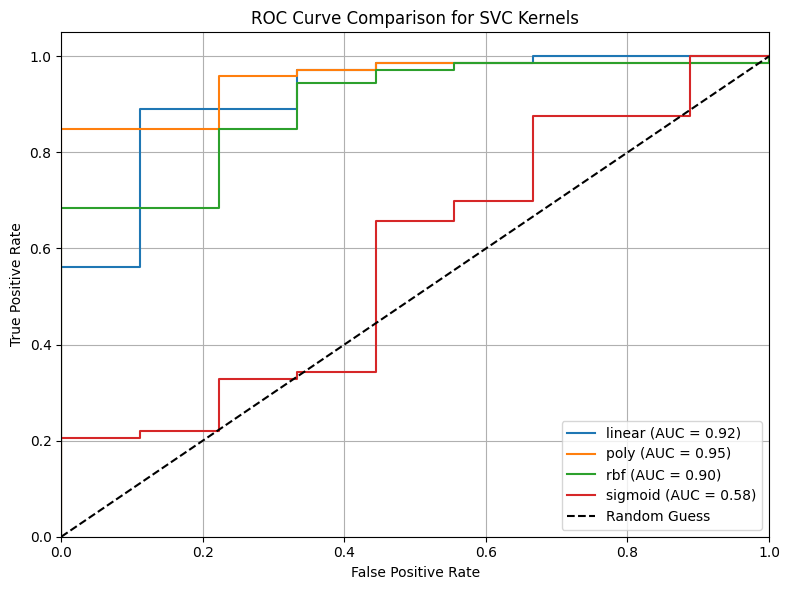

In [21]:
for res in svc_results:
    kernel = res["Kernel"]
    np.save(f"y_test_svc_{kernel}.npy", np.array(res["y_test"]))
    np.save(f"y_pred_svc_{kernel}.npy", np.array(res["y_pred"]))
    np.save(f"y_prob_svc_{kernel}.npy", np.array(res["y_prob"]))

print(res["y_prob"])
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))
plt.title("ROC Curve Comparison for SVC Kernels")

for res in svc_results:
    kernel = res["Kernel"]
    y_test_arr = np.array(res["y_test"])
    y_prob_arr = np.array(res["y_prob"])

    fpr, tpr, _ = roc_curve(y_test_arr, y_prob_arr)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{kernel} (AUC = {roc_auc:.2f})")

# Reference line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig("svc_kernels_roc_comparison.png")
plt.show()

